# Crop Emulator based on Liu et al. 2023

## Variables for for irrigated emulators

### 1) XGBoost Models can be found here: https://zenodo.org/record/7796686
- for each Crop Model, Scenario (A0 or A1) crop type (winter wheat, spring wheat, maize, rice) and irrigation type (rainfed or irrigated)
- try with crop emulator: XGBpred38_GEPIC_A0_swh_rf
    - rainfed: water supply is only precipitation
        - reason: compound events are dry and hot, therfore we want the effect of drieness too
    - spring wheat: good results and important for europe
    - A0: maximum effect of climate change, no adaption (A1: this means adaption to higher Temperatures, in this scenario farmers pick a plant that is adapted to higher temperatures and therfore is less affected by rising temperatures; in the model this is done by setting up the optimal growing degree days for the crop -> this results in the same like shifting from for example winter wheat to spring wheat)
    - crop model: GEPIC, as defined in baseline study
    - unit of predictor: t/ha

    -> we need to find predictors for exactly this configuration

    - **keep in mind for AI RARES**
        - climate data: will be later given by AI RARES CAMulator, so its not that important for now which we use as we chnage them later anyways
        - crop specific data: may be not given by AI RARES, so we need to stick to Liu et al., 2023 hwhich data the used
        - open question: WP1.2: Calibration of GeoEPIC for the European context (PhD2): will crop specific data be used here and maybe is available?
        - list of crop specific predicotrs (everthying not from climate model output):
            - Growing season dates -> most important
                - planting date
                - growing season length
            - soil type
            - nitrogen fertilizer application
            - maybe: CO2 concentration


### 1.1) Crop yield data from GGCMI Phase 2
- crop yield data from GGCMI Phase 2 can be found here:
    - for GEPIC, spring wheat A0 and A1:
    - https://zenodo.org/records/2582263
- data in general on zndo: https://zenodo.org/

### 1.2) Our configuration of the predictor XGBpred38_GEPIC_A0_swh_rf
- crop model = GEPIC
- CO2 = 360 (manually set)
- N = 60
- T = 0 (baseline, but trained on multiple T levels)
- W = 0 (should work with multiple w levels becaues its trained on multiple w levels, but as we take rainfed as reference (no water ), its probably best to go with w0)
- N = 200 (manually set)
- A0 (given by file)

- so we need this y true data: gepic_agmerra_fullharm_yield_swh_global_annual_1980_2010_C360_T0_W0_N60_A0.nc4

- 



### 2) Documentation of the predictors can be found here: https://zenodo.org/records/7796686
- word document:Emulator function description.docx

- **Predictors for XGBpred38_GEPIC_A0_swh_rf**

The written documentation describes the predictor types, but inspection of the serialized Booster shows a different monthly column order. The exact order used in this notebook is documented in the following mapping cell.



### 2.1) Actual XGBoost feature mapping used by the serialized Booster

The written predictor documentation groups the monthly variables by climate variable. However, the split values in the serialized `XGBpred38_GEPIC_A0_swh_rf` Booster show that its **actual feature order is interleaved by month**:

| Month since planting | Tmax mean (degC) | Tmin mean (degC) | Solar mean (MJ m-2 day-1) | Precipitation total (mm) |
|---:|---|---|---|---|
| 1 | `f0` / `p00_tmax_mon1` | `f1` / `p01_tmin_mon1` | `f2` / `p02_solar_mon1` | `f3` / `p03_prec_mon1` |
| 2 | `f4` / `p04_tmax_mon2` | `f5` / `p05_tmin_mon2` | `f6` / `p06_solar_mon2` | `f7` / `p07_prec_mon2` |
| 3 | `f8` / `p08_tmax_mon3` | `f9` / `p09_tmin_mon3` | `f10` / `p10_solar_mon3` | `f11` / `p11_prec_mon3` |
| 4 | `f12` / `p12_tmax_mon4` | `f13` / `p13_tmin_mon4` | `f14` / `p14_solar_mon4` | `f15` / `p15_prec_mon4` |
| 5 | `f16` / `p16_tmax_mon5` | `f17` / `p17_tmin_mon5` | `f18` / `p18_solar_mon5` | `f19` / `p19_prec_mon5` |
| 6 | `f20` / `p20_tmax_mon6` | `f21` / `p21_tmin_mon6` | `f22` / `p22_solar_mon6` | `f23` / `p23_prec_mon6` |
| 7 | `f24` / `p24_tmax_mon7` | `f25` / `p25_tmin_mon7` | `f26` / `p26_solar_mon7` | `f27` / `p27_prec_mon7` |
| 8 | `f28` / `p28_tmax_mon8` | `f29` / `p29_tmin_mon8` | `f30` / `p30_solar_mon8` | `f31` / `p31_prec_mon8` |
| 9 | `f32` / `p32_tmax_mon9` | `f33` / `p33_tmin_mon9` | `f34` / `p34_solar_mon9` | `f35` / `p35_prec_mon9` |
| 10 | `f36` / `p36_tmax_mon10` | `f37` / `p37_tmin_mon10` | `f38` / `p38_solar_mon10` | `f39` / `p39_prec_mon10` |

Monthly windows run from the planting day to the day before the same day in the next calendar month. The monthly variables have no fixed physical threshold; XGBoost learns many split thresholds from the training data.

| XGBoost feature | Predictor variable | Predictor | Unit / definition |
|---|---|---|---|
| `f40` | `p40_gdd` | Growing degree days | degree days; spring wheat: low = 5 degC, high = 30 degC |
| `f41` | `p41_edd` | Extreme degree days | degree days; cumulative Tmax above 30 degC |
| `f42` | `p42_gs_avg_tmax` | Growing-season mean Tmax | degC |
| `f43` | `p43_gs_avg_tmin` | Growing-season mean Tmin | degC |
| `f44` | `p44_gs_total_prec` | Growing-season total precipitation | mm |
| `f45` | `p45_gs_avg_solar` | Growing-season mean solar radiation | MJ m-2 day-1 |
| `f46` | `p46_gs_sd_tmax` | Growing-season SD Tmax | degC |
| `f47` | `p47_gs_sd_tmin` | Growing-season SD Tmin | degC |
| `f48` | `p48_gs_sd_prec` | Growing-season SD daily precipitation | mm day-1 |
| `f49` | `p49_gs_sd_solar` | Growing-season SD daily solar radiation | MJ m-2 day-1 |
| `f50` | `p50_consecutive_drought_days` | Maximum consecutive dry days | days; daily precipitation = 0 |
| `f51` | `p51_soil_type` | HWSD USDA soil texture class | class 1-13 |
| `f52` | `p52_co2_ppm` | CO2 concentration | ppm |
| `f53` | `p53_n_fertilizer_kg_ha` | Nitrogen fertilizer application | kg ha-1 |
| `f54` | `p54_growing_season_length` | Spatial difference term / growing-season length | days |

The mapping is independently supported by characteristic first-tree splits such as `f52 < 510` for CO2, `f53 < 60` for nitrogen, `f54 < 100` for growing-season length, and the precipitation-like values of every fourth monthly feature (`f3`, `f7`, ..., `f39`). Solar radiation is converted from CESM2 `FSDS` in W m-2 to daily energy in MJ m-2 day-1 using `FSDS * 0.0864`, which matches the Booster's solar split ranges.


### 3) Data Sources for the Predictors
- GGCMI Phase 2 datasets can be found here: https://zenodo.org/records/3773827
- proivides 3 data sets, all for global coverage with saptial resolution of 0.5°:
    - Growing Season length, Sason start, season end
    - boolean mask for croplands
    - boolean mask for swh, wwh

- soil database can be found here: https://www.fao.org/soils-portal/soil-survey/soil-maps-and-databases/harmonized-world-soil-database-v12/en/
    - more infromation on the soil database can be found here: https://www.researchgate.net/publication/228068266_The_Harmonized_World_Soil_Database
    - its not clearly stated in Liu et al, which soil type data they used
    - I guess they used the variable: T_USDA_TEX_CLASS
        - it contains 13 soil types from sand to heavy clay, which is stated in the paper


# Climate Data

## AGMERRA Data
- the agmerra data can be found here: https://data.giss.nasa.gov/impacts/agmipcf/agmerra/

## CESM2 Data
- CESM2 data can be found on the uni Server here: /climca/data/CESM2_LE
    - temperature: /climca/data/CESM2_LE/TREFHT/day_processed
- to donwload from website use this linbk: https://gdex.ucar.edu/datasets/d651056/dataaccess/
    - i selected: b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.FSDS and than the right time period
    - uses a python donwload script


### CESM Filename Convention

Example:
b.e21.BSSP370cmip6.f09_g17.LE2-1001.001.cam.h1.FSDS.20150101-20241231.nc

- e21 → CESM2 generation
- BSSP370cmip6 → scenario/experiment, could also be historical if data is before 2015
- f09_g17 → model grid
- LE2-1001 → ensemble member
- cam → atmosphere model
- h1 → daily output
- FSDS → variable
- 20150101-20241231 → file time span

### Processed Files

Example:
b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHTMN.1850-2100.nc

Differences:
- scenario name often removed
- many raw files merged into one
- full simulation period in one file

Usually stored in:
- day_raw/ → original chunked CESM output
- day_processed/ → merged/cleaned files

### Common Variables

- FSDS → incoming solar radiation
- FSNS → net surface shortwave radiation
- FLNT → top-of-atmosphere longwave radiation
- TREFHT → 2m air temperature
- TREFHTMN → daily Tmin
- TREFHTMX → daily Tmax

### Naming Logic

- F = flux
- S = shortwave
- L = longwave
- D = downwelling
- N = net
- MN = minimum
- MX = maximum

### Constraint Variables in historical period of CESM2

- atmospheric CO₂, CH₄, N₂O
- anthropogenic aerosols
- volcanic eruptions
- solar irradiance changes
- land-use / land-cover changes
- ozone forcing


## Load and inspect XGBoost model

In [105]:
# ============================================================
# 0. Imports
# ============================================================

import os
import warnings
import json
import joblib
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pprint
import rasterio

# Suppress expected runtime warnings caused by NaN values in masked grid cells.
warnings.filterwarnings("ignore", category=RuntimeWarning)



In [106]:
# ============================================================
# 1. Define paths
# ============================================================

data_dir = "/home/pmahlau/Uni_Arbeit/data/crop_data"

old_model_file = "XGBpred38_GEPIC_A0_swh_rf"
json_model_file = "XGBpred38_GEPIC_A0_swh_rf.json"

old_model_path = os.path.join(data_dir, old_model_file)
json_model_path = os.path.join(data_dir, json_model_file)

print("XGBoost version:", xgb.__version__)
print("Old model path:", old_model_path)

XGBoost version: 1.7.6
Old model path: /home/pmahlau/Uni_Arbeit/data/crop_data/XGBpred38_GEPIC_A0_swh_rf


In [107]:
# ============================================================
# 2. Load old serialized model
# ============================================================

model = joblib.load(old_model_path)

print("Loaded object type:")
print(type(model))

[14:36:26] WARNING: ../src/learner.cc:1203: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[14:36:26] WARNING: ../src/learner.cc:888: Found JSON model saved before XGBoost 1.6, please save the model using current version again. The support for old JSON model will be discontinued in XGBoost 2.3.
[14:36:26] WARNING: ../src/learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details a

In [108]:
# ============================================================
# 3. Extract Booster and save as stable JSON
# ============================================================

booster_old = model.get_booster()

booster_old.save_model(json_model_path)

print("Saved converted JSON model to:")
print(json_model_path)

Saved converted JSON model to:
/home/pmahlau/Uni_Arbeit/data/crop_data/XGBpred38_GEPIC_A0_swh_rf.json


In [109]:
# ============================================================
# 4. Reload JSON model as pure XGBoost Booster
# ============================================================

booster = xgb.Booster()
booster.load_model(json_model_path)

print("Reloaded JSON Booster:")
print(type(booster))


Reloaded JSON Booster:
<class 'xgboost.core.Booster'>


In [110]:
# ============================================================
# 5. Basic model inspection
# ============================================================

print("Number of features:")
print(booster.num_features())

print("Number of boosted rounds / trees:")
print(booster.num_boosted_rounds())

print("Feature names:")
print(booster.feature_names)


Number of features:
55
Number of boosted rounds / trees:
4000
Feature names:
None


In [111]:
# ============================================================
# 6. Inspect full XGBoost configuration
# ============================================================

config = json.loads(booster.save_config())

print(json.dumps(config, indent=2))


{
  "learner": {
    "generic_param": {
      "fail_on_invalid_gpu_id": "0",
      "gpu_id": "-1",
      "n_jobs": "0",
      "nthread": "0",
      "random_state": "0",
      "seed": "0",
      "seed_per_iteration": "0",
      "validate_parameters": "1"
    },
    "gradient_booster": {
      "gbtree_model_param": {
        "num_parallel_tree": "1",
        "num_trees": "4000",
        "size_leaf_vector": "0"
      },
      "gbtree_train_param": {
        "predictor": "auto",
        "process_type": "default",
        "tree_method": "auto",
        "updater": "grow_colmaker,prune",
        "updater_seq": "grow_colmaker,prune"
      },
      "name": "gbtree",
      "specified_updater": false,
      "updater": {
        "grow_colmaker": {
          "colmaker_train_param": {
            "default_direction": "learn",
            "opt_dense_col": "1"
          },
          "train_param": {
            "alpha": "0",
            "cache_opt": "1",
            "colsample_bylevel": "1",
         

In [112]:

# ============================================================
# 7. Feature importance
# ============================================================

importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")
importance_cover = booster.get_score(importance_type="cover")

importance_df = pd.DataFrame({
    "feature": list(importance_gain.keys()),
    "gain": list(importance_gain.values())
}).sort_values("gain", ascending=False)

print("Feature importance by gain:")
print(importance_df.head(30))

print(importance_weight)

Feature importance by gain:
   feature        gain
42     f42  604.325928
44     f44  403.836700
54     f54  208.180191
34     f34   93.960861
41     f41   86.533737
51     f51   71.819389
53     f53   65.871880
36     f36   63.831661
30     f30   51.530949
47     f47   48.704239
31     f31   46.270462
40     f40   40.713516
35     f35   38.942993
38     f38   38.495243
21     f21   38.112610
26     f26   37.155300
46     f46   33.656746
27     f27   33.118782
45     f45   30.185583
23     f23   29.474819
25     f25   27.618505
32     f32   27.609713
39     f39   27.265699
22     f22   24.610764
52     f52   24.458424
37     f37   24.309553
33     f33   23.028030
48     f48   22.925756
24     f24   22.721210
29     f29   22.523146
{'f0': 180376.0, 'f1': 50607.0, 'f2': 99806.0, 'f3': 187638.0, 'f4': 42974.0, 'f5': 30885.0, 'f6': 75862.0, 'f7': 101798.0, 'f8': 34691.0, 'f9': 26759.0, 'f10': 70723.0, 'f11': 90106.0, 'f12': 31661.0, 'f13': 25121.0, 'f14': 69162.0, 'f15': 85082.0, 'f16': 30

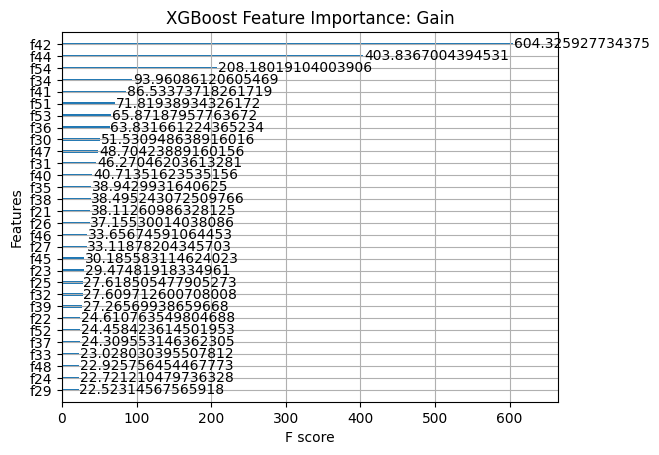

In [113]:
# ============================================================
# 8. Plot feature importance
# ============================================================

xgb.plot_importance(
    booster,
    importance_type="gain",
    max_num_features=30
)

plt.title("XGBoost Feature Importance: Gain")
plt.show()


In [114]:
# ============================================================
# 9. Inspect tree structure as table
# ============================================================

trees_df = booster.trees_to_dataframe()

print("Tree dataframe shape:")
print(trees_df.shape)

print("First rows of tree dataframe:")
print(trees_df.head())


Tree dataframe shape:
(6930776, 11)
First rows of tree dataframe:
   Tree  Node   ID Feature       Split   Yes    No Missing         Gain  \
0     0     0  0-0     f44  120.849998   0-1   0-2     0-1  4614682.000   
1     0     1  0-1     f34    2.830645   0-3   0-4     0-4   610095.688   
2     0     2  0-2     f53   60.000000   0-5   0-6     0-5  3261410.000   
3     0     3  0-3     f39   10.797501   0-7   0-8     0-7    85199.000   
4     0     4  0-4     f44   77.130005  0-11  0-12    0-11   333905.812   

        Cover  Category  
0  21852058.0       NaN  
1   5803887.0       NaN  
2  16048171.0       NaN  
3   1133849.0       NaN  
4   4670038.0       NaN  


In [115]:


# ============================================================
# 10. Inspect one tree as text
# ============================================================

tree_dump = booster.get_dump()

print("Number of trees:")
print(len(tree_dump))

print("First tree:")
print(tree_dump[0])

Number of trees:
4000
First tree:
0:[f44<120.849998] yes=1,no=2,missing=1
	1:[f34<2.83064508] yes=3,no=4,missing=4
		3:[f39<10.7975006] yes=7,no=8,missing=7
			7:[f31<19.3325005] yes=15,no=16,missing=16
				15:[f42<23.2597599] yes=31,no=32,missing=31
					31:[f27<19.8450012] yes=63,no=64,missing=64
						63:[f48<1.98238516] yes=127,no=128,missing=127
							127:[f35<16.2224998] yes=255,no=256,missing=255
								255:[f3<22.5550003] yes=511,no=512,missing=511
									511:[f27<11.6750002] yes=1023,no=1024,missing=1023
										1023:leaf=-0.00563795678
										1024:leaf=0.0203634594
									512:[f11<67.5400009] yes=2043,no=2044,missing=2043
										2043:leaf=0.0406616405
										2044:leaf=0.125809208
								256:[f37<-16.5943546] yes=1019,no=1020,missing=1019
									1019:[f23<26.8400002] yes=1045,no=1046,missing=1046
										1045:leaf=0.0217799395
										1046:leaf=0.0775871128
									1020:[f34<1.14677417] yes=1041,no=1042,missing=1041
										1041:leaf=0.110797465
				

## GGCMI Phase 2 datasets

<xarray.Dataset>
Dimensions:                (lon: 720, lat: 360)
Coordinates:
  * lon                    (lon) float64 -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat                    (lat) float64 -89.75 -89.25 -88.75 ... 89.25 89.75
Data variables:
    harvest day            (lat, lon) float32 ...
    planting day           (lat, lon) float32 ...
    growing season length  (lat, lon) float32 ...
    data source used       (lat, lon) float32 ...
Attributes:
    title:     prescribed planting and harvest dates for Ag-GRID GGCMI harmon...
    comment1:  areas where fastest-maturing variety should be used are flagge...
    comment2:  areas where no suitable sowing date could be derived are flagg...
    comment3:  dates created from LPJmL rule based dates (Waha et al. 2012), ...
<xarray.Dataset>
Dimensions:        (lon: 720, lat: 360)
Coordinates:
  * lon            (lon) float64 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * lat            (lat) float64 -89.75 -89.25 -88.75 ... 88.75 89.2

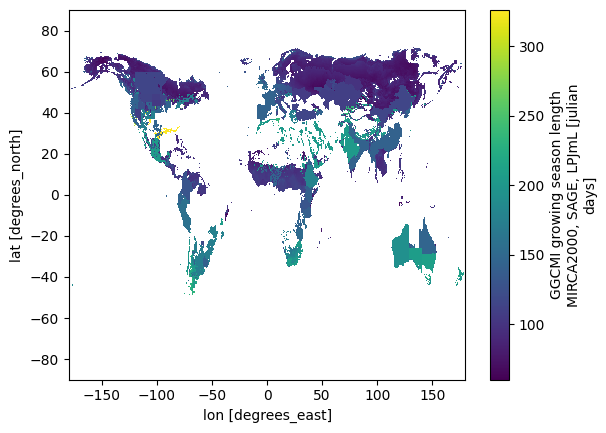

In [116]:
# growing season data
import os

data_dir_agmip = r"../data/crop_data/ggcmi_phase_2_data/AGMIP_GROWING_SEASON.HARM.version2.0/"
file_swh = "swh_rf_growing_season_dates_v2.nc4"

data_path = os.path.join(data_dir_agmip, file_swh)

ds = xr.open_dataset(data_path, engine = "netcdf4")
print(ds)
grow_season = ds["growing season length"]
grow_season.plot()

fertilizer = xr.open_dataset(data_dir_agmip + "swh_rf_2nd_fertilizer_days_disseminate_v2.nc4", engine = "netcdf4")
print(fertilizer)

# fertilizer["2nd fert appl"].plot()

<xarray.Dataset>
Dimensions:                (lon: 720, lat: 360)
Coordinates:
  * lon                    (lon) float64 -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat                    (lat) float64 -89.75 -89.25 -88.75 ... 89.25 89.75
Data variables:
    minimum cropland mask  (lat, lon) float32 ...
Attributes:
    title:      minimum cropland to be simulated in GGCMI phase 2 simulations
    author:     Christoph Mueller, PIK cmueller@pik-potsdam.de
    comment 1:  use this mask to mask out unsuitable areas from simulations f...
    comment 2:  unsuitability is based on GAEZ; Grid-cells are marked as unsi...
    comment 3:  unsuitability is neglected, if pixel is used for cropland (an...


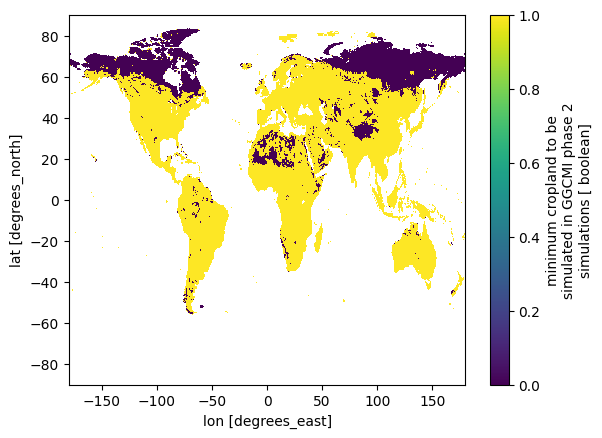

In [117]:
# cropmask

data_dir_ggcmi = r"../data/crop_data/ggcmi_phase_2_data"
file_swh = "boolean_cropmask_ggcmi_phase2.nc4"

data_path = os.path.join(data_dir_ggcmi, file_swh)

cropmask = xr.open_dataset(data_path, engine = "netcdf4")
print(cropmask) #cropmask
cropmask["minimum cropland mask"].plot()

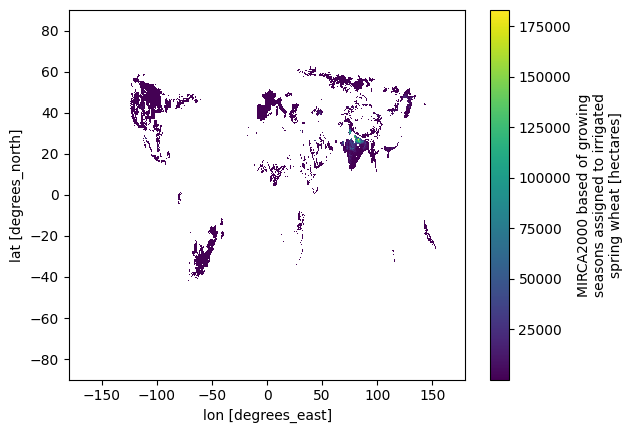

In [118]:
# winter and spring wheat areas 

spring_mask_file = "winter_and_spring_wheat_areas_v1_180627.nc4"

data_path = os.path.join(data_dir_ggcmi, spring_mask_file)

sw_mask = xr.open_dataset(data_path, engine = "netcdf4")
sw_mask["swh_ir_area"].plot()

## Soil Type Cover Data

- this part does not work on linux server 
- solution: executed on mac and exported as .csv file

In [119]:
# import rasterio
# import pandas as pd
# import subprocess
# import io

# # 1. Pfad setzen
# data_path = "/Users/patricemahlau/Documents/Uni_Leipzig_Arbeit/data/soil_data/"

# # 2. Raster laden (.bil benötigt .hdr im selben Ordner)
# with rasterio.open(data_path + "hwsd.bil") as src:
#     soil_raster = src.read(1)  # Das Array mit den MU_GLOBAL IDs
#     profile = src.profile      # Metadaten für späteres Speichern/Verschneiden

# # 3. Datenbank (.mdb) auslesen
# # Da pyodbc auf Mac oft scheitert, nutzen wir mdbtools direkt:
# def read_mdb_table(db_path, table_name):
#     cmd = ["mdb-export", db_path, table_name]
#     output = subprocess.run(cmd, capture_output=True, text=True)
#     return pd.read_csv(io.StringIO(output.stdout))

# # Tabelle 'HWSD_DATA' laden (enthält die Zuordnung ID -> Bodentyp)
# df_attr = read_mdb_table(data_path + "HWSD.mdb", "HWSD_DATA")

# # 4. Minimales Mapping Beispiel
# # Erstellt ein Dictionary: MU_GLOBAL -> Soil Type (z.B. SU_SYM90)
# id_to_type = dict(zip(df_attr['MU_GLOBAL'], df_attr['SU_SYM90']))

# print(f"Raster Shape: {soil_raster.shape}")
# print(f"Beispiel Mapping (ID 7001): {id_to_type.get(7001)}")

In [120]:
import rasterio
import pandas as pd

# 1. Pfad setzen
data_path = r"../data/crop_data/soil_data/"

# 2. Raster laden
with rasterio.open(data_path + "hwsd.bil") as src:
    soil_raster = src.read(1)
    profile = src.profile

# 3. Die konvertierte CSV-Datei direkt laden (Kein MDB-Ärger mehr!)
df_attr = pd.read_csv(data_path + "HWSD_DATA.csv")

# 4. Minimales Mapping Beispiel
id_to_type = dict(zip(df_attr['MU_GLOBAL'], df_attr['SU_SYM90']))

print(f"Raster Shape: {soil_raster.shape}")
print(f"Beispiel Mapping (ID 7001): {id_to_type.get(7001)}")

Raster Shape: (21600, 43200)
Beispiel Mapping (ID 7001): UR


/tmp/ipykernel_4000815/348297712.py:13: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attr = pd.read_csv(data_path + "HWSD_DATA.csv")


In [121]:
df_attr

,ID,MU_GLOBAL,MU_SOURCE1,MU_SOURCE2,ISSOIL,SHARE,SEQ,SU_SYM74,SU_CODE74,SU_SYM85,...,S_CEC_CLAY,S_CEC_SOIL,S_BS,S_TEB,S_CACO3,S_CASO4,S_ESP,S_ECE,T_BULK_DENSITY,S_BULK_DENSITY
0,2,7002,2,2.0,0,100.0,1,NaN,NaN,HD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,7003,3,3.0,0,100.0,1,NaN,NaN,WR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,7004,4,4.0,0,100.0,1,NaN,NaN,Od,...,71.0,78.0,40.0,27.4,0.0,0.0,1.0,0.1,0.10,0.10
3,5,7005,5,5.0,0,100.0,1,NaN,NaN,GG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,7006,70001,70001.0,1,70.0,1,NaN,NaN,Tv,...,146.0,10.0,23.0,5.3,0.0,0.0,1.0,0.1,0.99,0.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48143,48145,32049,TN249,NaN,1,20.0,4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.30,NaN
48144,48146,32050,TN250,NaN,1,50.0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.30,NaN
48145,48147,32050,TN250,NaN,1,30.0,2,NaN,NaN,NaN,...,37.0,3.0,100.0,3.1,5.7,0.1,4.0,1.0,1.50,1.49
48146,48148,32050,TN250,NaN,1,20.0,3,NaN,NaN,NaN,...,27.0,4.0,90.0,3.6,3.0,0.2,2.0,0.1,1.16,1.14


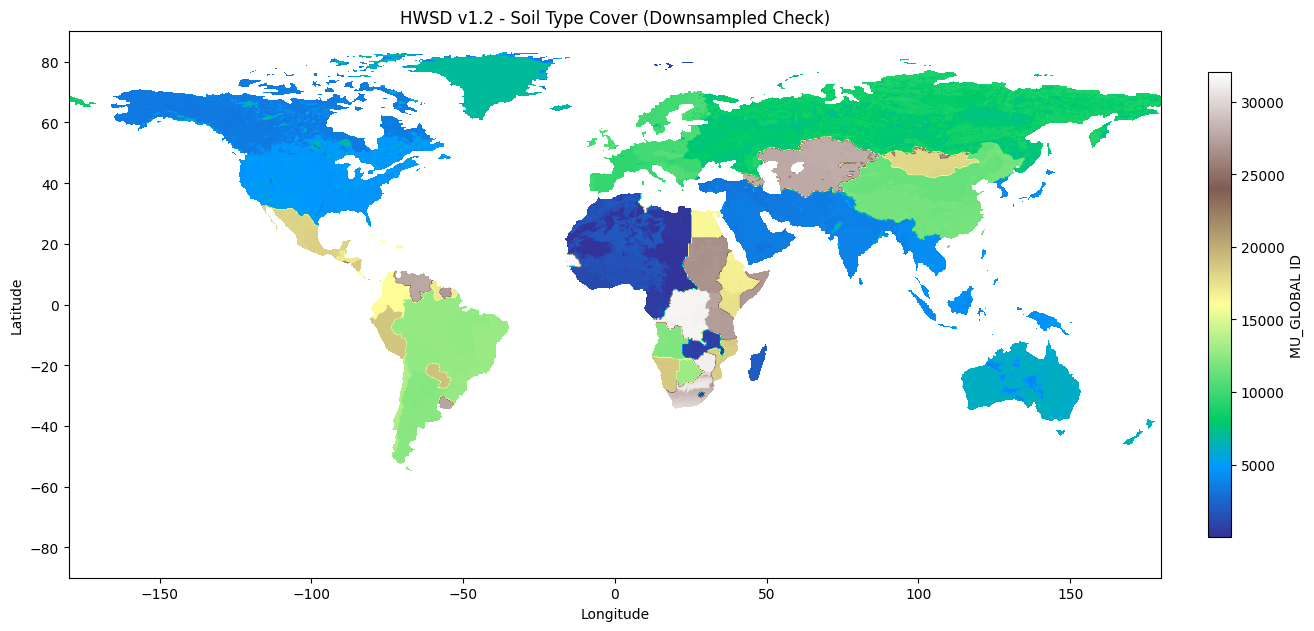

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Daten für den Plot vorbereiten (Downsampling auf 10% für Speed)
# Wir nutzen [::10, ::10] um nur jeden 10. Pixel zu nehmen
plot_data = soil_raster[::10, ::10].astype(float)

# 2. No-Data Werte maskieren (in HWSD v1.2 oft 0)
plot_data[plot_data == 0] = np.nan

# 3. Plot erstellen
plt.figure(figsize=(15, 8))
img = plt.imshow(plot_data, cmap='terrain', extent=[-180, 180, -90, 90])
plt.colorbar(img, label='MU_GLOBAL ID', fraction=0.02, pad=0.04)

plt.title("HWSD v1.2 - Soil Type Cover (Downsampled Check)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [123]:
import numpy as np

# 1. Erstelle ein Mapping-Array (Index = MU_GLOBAL, Wert = Texture Class)
# Wir finden die höchste ID, um die Größe des Arrays festzulegen
max_id = int(df_attr['MU_GLOBAL'].max())
# Initialisiere mit 0 (für Wasser/NoData)
mapping_array = np.zeros(max_id + 1, dtype=np.float32) 

# Fülle das Array mit den Werten aus der Datenbank
for _, row in df_attr.iterrows():
    mapping_array[int(row['MU_GLOBAL'])] = row['T_USDA_TEX_CLASS']

# 2. Das eigentliche Mapping (Blitzschnell)
# Wir behandeln NaN im soil_raster vorab:
soil_raster_clean = np.nan_to_num(soil_raster, nan=0).astype(int)

# Hier passiert die Magie: Jeder Wert im Raster wird als Index für das Mapping-Array genutzt
texture_raster = mapping_array[soil_raster_clean]

# 3. Jetzt kannst du die NaNs wieder setzen, wo vorher Wasser (0) war
texture_raster[texture_raster == 0] = np.nan

print("Texture Raster erfolgreich erstellt!")


Texture Raster erfolgreich erstellt!


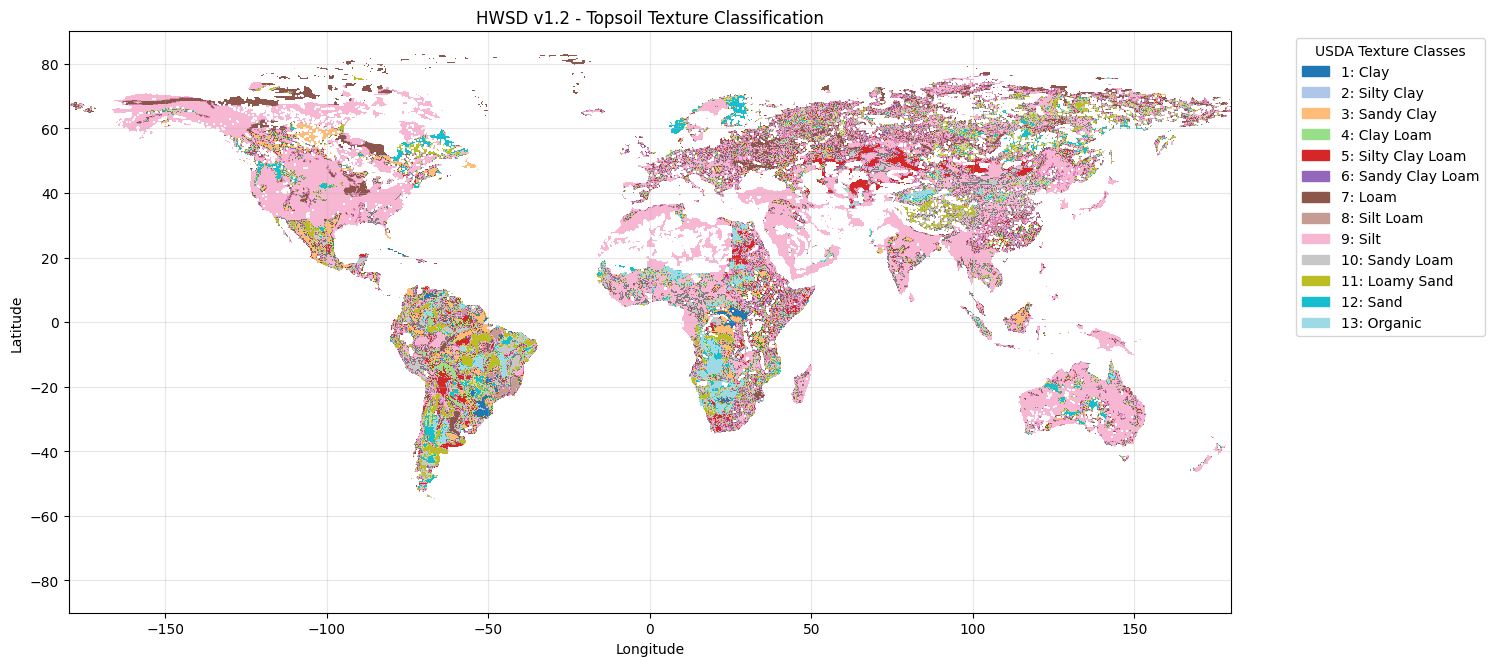

In [124]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Namen der USDA Klassen laut Dokumentation
tex_names = {
    1: "Clay", 2: "Silty Clay", 3: "Sandy Clay", 4: "Clay Loam", 
    5: "Silty Clay Loam", 6: "Sandy Clay Loam", 7: "Loam", 
    8: "Silt Loam", 9: "Silt", 10: "Sandy Loam", 
    11: "Loamy Sand", 12: "Sand", 13: "Organic"
}

# 2. Plot Setup
plt.figure(figsize=(15, 8))

# Wir nutzen einen Ausschnitt (Downsampling), um den RAM zu schonen
# cmap 'tab20' bietet gute Unterscheidung für die 13 Klassen
im = plt.imshow(texture_raster[::20, ::20], cmap='tab20', 
                extent=[-180, 180, -90, 90])

# 3. Legende manuell erstellen
# Wir holen uns die Farben aus der Map, die tatsächlich im Raster vorkommen
colors = [im.cmap(im.norm(i)) for i in tex_names.keys()]
patches = [mpatches.Patch(color=colors[i-1], label=f"{i}: {tex_names[i]}") 
           for i in tex_names.keys()]

plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="USDA Texture Classes")

plt.title("HWSD v1.2 - Topsoil Texture Classification")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.3)

plt.show()

## Climate Data CESM 2

<xarray.DataArray 'TREFHTMX' (time: 91617, lat: 192, lon: 288)>
[5066053632 values with dtype=float32]
Coordinates:
  * time     (time) object 1850-01-01 00:00:00 ... 2101-01-01 00:00:00
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    long_name:     Maximum reference height temperature over output period
    units:         K
    cell_methods:  time: maximum


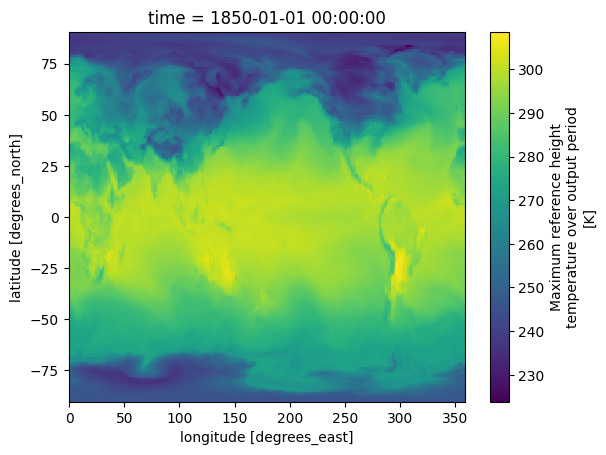

In [125]:
#inspect climate CESM 2 data we have: tas max 
import xarray as xr

data = xr.open_dataset(r"/climca/data/CESM2_LE/TREFHTMX/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHTMX.1850-2100.nc", engine = "netcdf4")
tmax = data["TREFHTMX"]
tmax.isel(time=0).plot()
print(tmax)

<xarray.DataArray 'TREFHTMN' (time: 91617, lat: 192, lon: 288)>
[5066053632 values with dtype=float32]
Coordinates:
  * time     (time) object 1850-01-01 00:00:00 ... 2101-01-01 00:00:00
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    long_name:     Minimum reference height temperature over output period
    units:         K
    cell_methods:  time: minimum

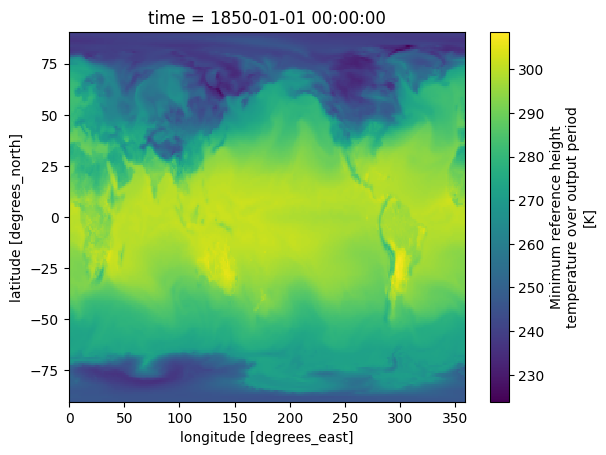

In [126]:
#inspect climate CESM 2 data we have: tas max 
import xarray as xr

data = xr.open_dataset(r"/climca/data/CESM2_LE/TREFHTMN/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHTMN.1850-2100.nc", engine = "netcdf4")
tmin = data["TREFHTMN"]
tmin.isel(time=0).plot()
display(tmin)

<xarray.DataArray 'PRECT' (time: 91617, lat: 192, lon: 288)>
[5066053632 values with dtype=float32]
Coordinates:
  * time     (time) object 1850-01-01 00:00:00 ... 2101-01-01 00:00:00
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    long_name:     Total (convective and large-scale) precipitation rate (liq...
    units:         m/s
    cell_methods:  time: mean


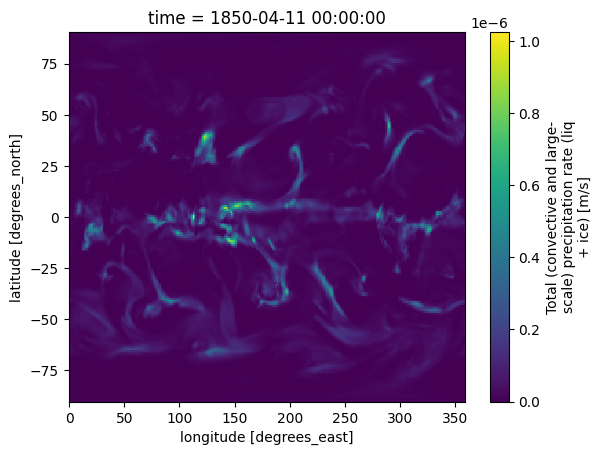

In [127]:
# precipitation
data = xr.open_dataset(r"/climca/data/CESM2_LE/PRECT/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.PRECT.1850-2100.nc", engine = "netcdf4")
prec = data["PRECT"]
prec.isel(time=100).plot()
print(prec)

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 1980-01-01 00:00:00 ... 2009-12-31 00:00:00
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Dimensions without coordinates: bnds
Data variables: (12/14)
    time_bnds  (time, bnds) object ...
    gw         (lat) float64 ...
    date       (time) float64 ...
    datesec    (time) float64 ...
    ndcur      (time) float64 ...
    nscur      (time) float64 ...
    ...         ...
    n2ovmr     (time) float64 ...
    f11vmr     (time) float64 ...
    f12vmr     (time) float64 ...
    sol_tsi    (time) float64 ...
    nsteph     (time) float64 ...
    FSDS       (time, lat, lon) float32 ...
Attributes:
    CDI:               Climate Data Interface version 2.1.0 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.B

<xarray.DataArray 'FSDS' (time: 10950, lat: 192, lon: 288)>
[605491200 values with dtype=float32]
Coordinates:
  * time     (time) object 1980-01-01 00:00:00 ... 2009-12-31 00:00:00
  * lat      (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 87.17 88.12 89.06 90.0
  * lon      (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    long_name:          Downwelling solar flux at surface
    units:              W/m2
    Sampling_Sequence:  rad_lwsw
    cell_methods:       time: mean

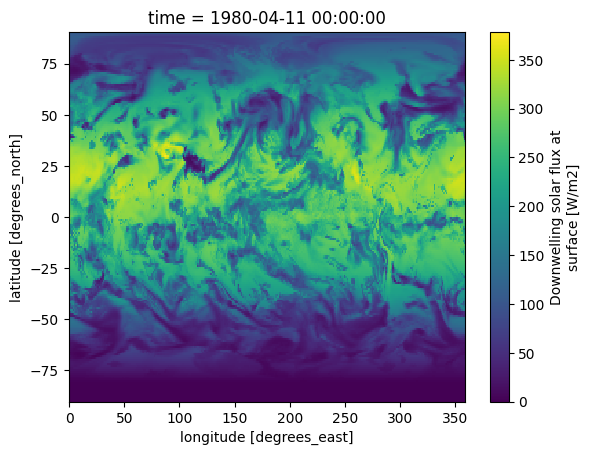

In [128]:
# solar radiation

data = xr.open_dataset(r"/home/pmahlau/Uni_Arbeit/data/CESM2/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.FSDS.19800101-20091231.nc", engine = "netcdf4")
print(data)
solar = data["FSDS"]
solar.isel(time=100).plot()
display(solar)

## Climate Data: Agmerra

In [26]:
import os
import xarray as xr
import matplotlib.pyplot as plt

data_dir = r"/home/pmahlau/Uni_Arbeit/data/agmerra/agmerra_data"

# Loop through the files in the directory
for file in os.listdir(data_dir):
    if file.startswith("AgMERRA_1980"):
        
        var_name = os.path.splitext(file)[0]
        file_path = os.path.join(data_dir, file)
        
        # Open the dataset
        ds = xr.open_dataset(file_path, engine="netcdf4", decode_times=False)
        
        # Find the inner variable name (like 'tmax' or 'tavg')
        for v in ds.data_vars:
            if v in var_name:
                # This magic line creates a real Python variable named after 'v'
                globals()[v] = ds[v]
                print(f"Created independent variable: {v}")

print("\n--- All variables are now loaded! ---")

print(prate) #prate
print(tmax)
print(tmin)
print(srad)

Created independent variable: tavg
Created independent variable: rhstmax
Created independent variable: srad
Created independent variable: wndspd
Created independent variable: tmax
Created independent variable: tmin
Created independent variable: prate

--- All variables are now loaded! ---
<xarray.DataArray 'prate' (time: 366, latitude: 720, longitude: 1440)>
[379468800 values with dtype=float32]
Coordinates:
  * time       (time) float32 0.0 1.0 2.0 3.0 4.0 ... 362.0 363.0 364.0 365.0
  * latitude   (latitude) float32 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Attributes:
    description:         Precipitation Rate
    units:               mm/day
    vMin_original_data:  0.0
    vMax_original_data:  457.4
    vRange:              457.4
<xarray.DataArray 'tmax' (time: 366, latitude: 720, longitude: 1440)>
[379468800 values with dtype=float32]
Coordinates:
  * time       (time) float32 0.0 1.0 2.0 3.0 4.0 ..

## Preprocessing Climate Data

In [129]:
# ============================================================
# Climate predictor preprocessing for Liu et al. crop emulator
# Test case:
# - CESM2-LE member LE2-1001
# - output years 1980-2009
# - spring wheat, rainfed
# - XGBoost features f0...f54 stored as predictors p00...p54
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import rasterio


# ============================================================
# 1. Paths and constants
# ============================================================

PATH_TMAX = "/climca/data/CESM2_LE/TREFHTMX/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHTMX.1850-2100.nc"
PATH_TMIN = "/climca/data/CESM2_LE/TREFHTMN/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.TREFHTMN.1850-2100.nc"
PATH_PREC = "/climca/data/CESM2_LE/PRECT/day_processed/b.e21.f09_g17.LE2-1001.001.cam.h1.PRECT.1850-2100.nc"
PATH_FSDS = "/home/pmahlau/Uni_Arbeit/data/CESM2/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.FSDS.19800101-20091231.nc"

DATA_DIR_AGMIP = "../data/crop_data/ggcmi_phase_2_data/AGMIP_GROWING_SEASON.HARM.version2.0/"
PATH_GS = os.path.join(DATA_DIR_AGMIP, "swh_rf_growing_season_dates_v2.nc4")

DATA_DIR_GGCMI = "../data/crop_data/ggcmi_phase_2_data/"
PATH_MASK = os.path.join(DATA_DIR_GGCMI, "winter_and_spring_wheat_areas_v1_180627.nc4")

PATH_SOIL_RASTER = "../data/crop_data/soil_data/hwsd.bil"
PATH_SOIL_ATTR = "../data/crop_data/soil_data/HWSD_DATA.csv"

CO2_PPM = 360.0
N_FERT_KG_HA = 60.0

START_YEAR = 1980
END_YEAR = 2009

RESULTS_DIR = "/home/pmahlau/Uni_Arbeit/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

OUTFILE = os.path.join(
    RESULTS_DIR,
    f"predictors_XGBpred38_GEPIC_A0_swh_rf_LE2-1001_{START_YEAR}-{END_YEAR}.nc",
)


# ============================================================
# 2. Helper functions
# ============================================================

def open_var(path, varname):
    return xr.open_dataset(path, engine="netcdf4")[varname]


def subset_years(da, start_year, end_year):
    return da.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))


def lon_to_0_360(da):
    if da.lon.min() < 0:
        da = da.assign_coords(lon=(da.lon % 360)).sortby("lon")
    return da


def align_to_grid(source, target_grid, method="nearest"):
    source = lon_to_0_360(source)
    return source.interp(lat=target_grid.lat, lon=target_grid.lon, method=method)


def open_on_grid(path, varname, target_grid, method="nearest"):
    return align_to_grid(open_var(path, varname), target_grid, method=method)


def convert_units(tmax, tmin, prec, solar):
    """
    CESM units:
    - TREFHTMX/TREFHTMN: K -> degC
    - PRECT: m/s -> mm/day
    - FSDS: W/m2 -> MJ/m2/day
    """
    tmax = tmax - 273.15
    tmin = tmin - 273.15
    prec = prec * 1000 * 86400
    solar = solar * 0.0864

    tmax.attrs["units"] = "degC"
    tmin.attrs["units"] = "degC"
    prec.attrs["units"] = "mm/day"
    solar.attrs["units"] = "MJ/m2/day"

    return tmax, tmin, prec, solar


def crop_year_slice(da, year, max_days=730):
    """Select enough daily data for late planting dates and ten monthly windows."""
    start = f"{year}-01-01"
    end = str(pd.Timestamp(start) + pd.Timedelta(days=max_days - 1))[:10]
    return da.sel(time=slice(start, end))


def calendar_month_bounds(year, planting, month_idx):
    """Return 1-based day indices for planting-date-aligned calendar months."""
    jan_1 = pd.Timestamp(f"{year}-01-01")
    start_lookup = []
    end_lookup = []

    # Build one lookup value for each possible planting day of year.
    for doy in range(1, 367):
        planting_date = jan_1 + pd.Timedelta(days=doy - 1)
        start_date = planting_date + pd.DateOffset(months=month_idx - 1)
        end_date = planting_date + pd.DateOffset(months=month_idx) - pd.Timedelta(days=1)
        start_lookup.append((start_date - jan_1).days + 1)
        end_lookup.append((end_date - jan_1).days + 1)

    start_lookup = xr.DataArray(start_lookup, dims=["doy"])
    end_lookup = xr.DataArray(end_lookup, dims=["doy"])
    safe_doy = planting.fillna(1).round().astype(int).clip(min=1, max=366) - 1

    start = start_lookup.isel(doy=safe_doy).where(np.isfinite(planting))
    end = end_lookup.isel(doy=safe_doy).where(np.isfinite(planting))
    return start, end


def monthly_window_agg(da_year, year, planting, month_idx, agg="mean"):
    """Aggregate one planting-date-aligned calendar month and reject incomplete windows."""
    start, end = calendar_month_bounds(year, planting, month_idx)
    day_number = xr.DataArray(
        np.arange(1, da_year.sizes["time"] + 1),
        dims=["time"],
        coords={"time": da_year.time},
    )
    data = da_year.where((day_number >= start) & (day_number <= end))

    if agg == "mean":
        result = data.mean("time")
    elif agg == "sum":
        result = data.sum("time")
    else:
        raise ValueError(f"unsupported agg: {agg}")

    # Prevent partial windows near the end of the available climate data.
    expected_days = end - start + 1
    return result.where(data.count("time") == expected_days)


def growing_season_mask(da_year, planting, gs_length):
    end = planting + gs_length - 1
    day_number = xr.DataArray(
        np.arange(1, da_year.sizes["time"] + 1),
        dims=["time"],
        coords={"time": da_year.time},
    )
    return (day_number >= planting) & (day_number <= end)


def growing_degree_days(tmean_gs, low=5, high=30):
    """Spring-wheat GDD: sum(max(min(Tmean, high) - low, 0))."""
    return (tmean_gs.clip(min=low, max=high) - low).clip(min=0).sum("time")


def positive_excess_sum(da, threshold):
    """Cumulative temperature above a threshold, used for EDD."""
    return xr.where(da > threshold, da - threshold, 0).sum("time")


def consecutive_drought_days(prec_gs):
    """Maximum consecutive growing-season days with exactly zero precipitation."""
    def max_run_1d(x):
        dry = (x == 0) & np.isfinite(x)
        max_run = 0
        run = 0

        for value in dry:
            if value:
                run += 1
                max_run = max(max_run, run)
            else:
                run = 0
        return max_run

    return xr.apply_ufunc(
        max_run_1d,
        prec_gs,
        input_core_dims=[["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )


def load_soil_texture_on_grid(path_raster, path_attr, target_grid):
    """Build HWSD soil texture classes 1..13 and align them to the climate grid."""
    with rasterio.open(path_raster) as src:
        soil_raster = src.read(1)

    df_attr = pd.read_csv(path_attr)
    max_id = int(df_attr["MU_GLOBAL"].max())
    mapping_array = np.zeros(max_id + 1, dtype=np.float32)

    for _, row in df_attr.iterrows():
        mapping_array[int(row["MU_GLOBAL"])] = row["T_USDA_TEX_CLASS"]

    soil_raster_clean = np.nan_to_num(soil_raster, nan=0).astype(int)
    texture_raster = mapping_array[soil_raster_clean]
    texture_raster[texture_raster == 0] = np.nan

    ny, nx = texture_raster.shape
    dlon = 360.0 / nx
    dlat = 180.0 / ny
    lon = np.linspace(-180.0 + dlon / 2, 180.0 - dlon / 2, nx)
    lat = np.linspace(90.0 - dlat / 2, -90.0 + dlat / 2, ny)

    texture_da = xr.DataArray(
        texture_raster,
        dims=["lat", "lon"],
        coords={"lat": lat, "lon": lon},
        name="soil_texture_class",
    )
    return align_to_grid(texture_da, target_grid, method="nearest")


def constant_on_grid(target_grid, value, name):
    arr = xr.full_like(target_grid, fill_value=float(value), dtype=np.float32)
    arr.name = name
    return arr



In [130]:
# ============================================================
# 3. Load climate data
# ============================================================

climate_specs = {
    "tmax": (PATH_TMAX, "TREFHTMX"),
    "tmin": (PATH_TMIN, "TREFHTMN"),
    "prec": (PATH_PREC, "PRECT"),
    "solar": (PATH_FSDS, "FSDS"),
}

climate = {name: open_var(path, var) for name, (path, var) in climate_specs.items()}

# Predictor years can require climate data from the following calendar year.
# If a source file does not contain those days, incomplete predictor windows
# are marked as NaN and excluded from prediction.
climate = {
    name: subset_years(da, START_YEAR, END_YEAR + 1)
    for name, da in climate.items()
}

# Use tmax as the common reference grid.
ref = climate["tmax"]
for name in ["tmin", "prec", "solar"]:
    climate[name] = align_to_grid(climate[name], ref, method="nearest")

tmax, tmin, prec, solar = convert_units(
    climate["tmax"], climate["tmin"], climate["prec"], climate["solar"]
)



In [131]:
# ============================================================
# 4. Load crop calendar + mask + static predictors
# ============================================================

planting = open_on_grid(PATH_GS, "planting day", tmax)
gs_length = open_on_grid(PATH_GS, "growing season length", tmax)
swh_area = open_on_grid(PATH_MASK, "swh_rf_area", tmax)
swh_mask = swh_area > 0

planting = planting.where(swh_mask)
gs_length = gs_length.where(swh_mask)

# static predictors
soil_type = load_soil_texture_on_grid(PATH_SOIL_RASTER, PATH_SOIL_ATTR, tmax).where(swh_mask)
co2_ppm = constant_on_grid(tmax.isel(time=0, drop=True), CO2_PPM, "co2_ppm").where(swh_mask)
n_fert = constant_on_grid(tmax.isel(time=0, drop=True), N_FERT_KG_HA, "n_fert_kg_ha").where(swh_mask)

# remove invalid crop cells
valid_crop = np.isfinite(planting) & np.isfinite(gs_length) & (gs_length > 0)



/tmp/ipykernel_4000815/1872654816.py:200: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_attr = pd.read_csv(path_attr)


In [132]:
# ============================================================
# 5. Build predictors for one crop year
# ============================================================

def build_predictors_one_year(
    year,
    tmax,
    tmin,
    prec,
    solar,
    planting,
    gs_length,
    soil_type,
    co2_ppm,
    n_fert,
    valid_crop,
):
    """Return XGBoost features f0...f54 as Dataset variables p00...p54."""

    # Up to two calendar years are selected so late planting dates and all ten
    # planting-date-aligned monthly windows can be covered.
    tmax_y = crop_year_slice(tmax, year)
    tmin_y = crop_year_slice(tmin, year)
    prec_y = crop_year_slice(prec, year)
    solar_y = crop_year_slice(solar, year)

    predictors = {}

    # f0-f39 are interleaved by month in the serialized Booster:
    # Tmax mean, Tmin mean, solar mean, precipitation total.
    for m in range(1, 11):
        feature = 4 * (m - 1)
        predictors[f"p{feature:02d}_tmax_mon{m}"] = monthly_window_agg(tmax_y, year, planting, m, agg="mean")
        predictors[f"p{feature + 1:02d}_tmin_mon{m}"] = monthly_window_agg(tmin_y, year, planting, m, agg="mean")
        predictors[f"p{feature + 2:02d}_solar_mon{m}"] = monthly_window_agg(solar_y, year, planting, m, agg="mean")
        predictors[f"p{feature + 3:02d}_prec_mon{m}"] = monthly_window_agg(prec_y, year, planting, m, agg="sum")

    mask_gs = growing_season_mask(tmax_y, planting, gs_length)
    tmax_gs = tmax_y.where(mask_gs)
    tmin_gs = tmin_y.where(mask_gs)
    prec_gs = prec_y.where(mask_gs)
    solar_gs = solar_y.where(mask_gs)
    tmean_gs = (tmax_gs + tmin_gs) / 2

    # Reject growing-season aggregates if any daily source is incomplete.
    required_days = gs_length.round()
    complete_gs = (
        (tmax_gs.count("time") == required_days)
        & (tmin_gs.count("time") == required_days)
        & (prec_gs.count("time") == required_days)
        & (solar_gs.count("time") == required_days)
    )

    # f40-f50: growing-season climate indicators
    predictors["p40_gdd"] = growing_degree_days(tmean_gs, low=5, high=30).where(complete_gs)
    predictors["p41_edd"] = positive_excess_sum(tmax_gs, threshold=30).where(complete_gs)
    predictors["p42_gs_avg_tmax"] = tmax_gs.mean("time").where(complete_gs)
    predictors["p43_gs_avg_tmin"] = tmin_gs.mean("time").where(complete_gs)
    predictors["p44_gs_total_prec"] = prec_gs.sum("time").where(complete_gs)
    predictors["p45_gs_avg_solar"] = solar_gs.mean("time").where(complete_gs)
    predictors["p46_gs_sd_tmax"] = tmax_gs.std("time").where(complete_gs)
    predictors["p47_gs_sd_tmin"] = tmin_gs.std("time").where(complete_gs)
    predictors["p48_gs_sd_prec"] = prec_gs.std("time").where(complete_gs)
    predictors["p49_gs_sd_solar"] = solar_gs.std("time").where(complete_gs)
    predictors["p50_consecutive_drought_days"] = consecutive_drought_days(prec_gs).where(complete_gs)

    # f51-f54: static predictors
    predictors["p51_soil_type"] = soil_type
    predictors["p52_co2_ppm"] = co2_ppm
    predictors["p53_n_fertilizer_kg_ha"] = n_fert
    predictors["p54_growing_season_length"] = gs_length

    ds_out = xr.Dataset(predictors).where(valid_crop)
    return ds_out.expand_dims(year=[year])



In [133]:
# ============================================================
# 6. Run preprocessing for 1980-2009
# ============================================================

all_years = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"processing {year}")
    ds_year = build_predictors_one_year(
        year=year,
        tmax=tmax,
        tmin=tmin,
        prec=prec,
        solar=solar,
        planting=planting,
        gs_length=gs_length,
        soil_type=soil_type,
        co2_ppm=co2_ppm,
        n_fert=n_fert,
        valid_crop=valid_crop,
    )
    all_years.append(ds_year)

predictors = xr.concat(all_years, dim="year")



processing 1980
processing 1981
processing 1982
processing 1983
processing 1984
processing 1985
processing 1986
processing 1987
processing 1988
processing 1989
processing 1990
processing 1991
processing 1992
processing 1993
processing 1994
processing 1995
processing 1996
processing 1997
processing 1998
processing 1999
processing 2000
processing 2001
processing 2002
processing 2003
processing 2004
processing 2005
processing 2006
processing 2007
processing 2008
processing 2009


In [134]:
# ============================================================
# 7. Save
# ============================================================

predictors.attrs["description"] = "XGBoost features f0-f54 stored as predictors p00-p54 for Liu et al. 2023 crop emulator"
predictors.attrs["crop"] = "spring wheat"
predictors.attrs["irrigation"] = "rainfed"
predictors.attrs["crop_model"] = "GEPIC"
predictors.attrs["scenario"] = "A0"
predictors.attrs["cesm_member"] = "LE2-1001"
predictors.attrs["years"] = f"{START_YEAR}-{END_YEAR}"
predictors.attrs["co2_ppm"] = CO2_PPM
predictors.attrs["n_fertilizer_kg_ha"] = N_FERT_KG_HA
predictors.attrs["notes"] = "Monthly features are interleaved by month (Tmax, Tmin, solar, precipitation); solar is MJ/m2/day; spring-wheat GDD low/high=5/30 degC; EDD threshold=30 degC; drought requires precipitation=0; monthly windows follow calendar months from planting date."

predictors.to_netcdf(OUTFILE)

print(predictors)
print(f"saved: {OUTFILE}")



<xarray.Dataset>
Dimensions:                       (year: 30, lat: 192, lon: 288)
Coordinates:
  * year                          (year) int64 1980 1981 1982 ... 2007 2008 2009
  * lat                           (lat) float64 -90.0 -89.06 ... 89.06 90.0
  * lon                           (lon) float64 0.0 1.25 2.5 ... 357.5 358.8
Data variables: (12/55)
    p00_tmax_mon1                 (year, lat, lon) float32 nan nan ... nan nan
    p01_tmin_mon1                 (year, lat, lon) float32 nan nan ... nan nan
    p02_solar_mon1                (year, lat, lon) float32 nan nan ... nan nan
    p03_prec_mon1                 (year, lat, lon) float64 nan nan ... nan nan
    p04_tmax_mon2                 (year, lat, lon) float32 nan nan ... nan nan
    p05_tmin_mon2                 (year, lat, lon) float32 nan nan ... nan nan
    ...                            ...
    p49_gs_sd_solar               (year, lat, lon) float32 nan nan ... nan nan
    p50_consecutive_drought_days  (year, lat, lon) floa

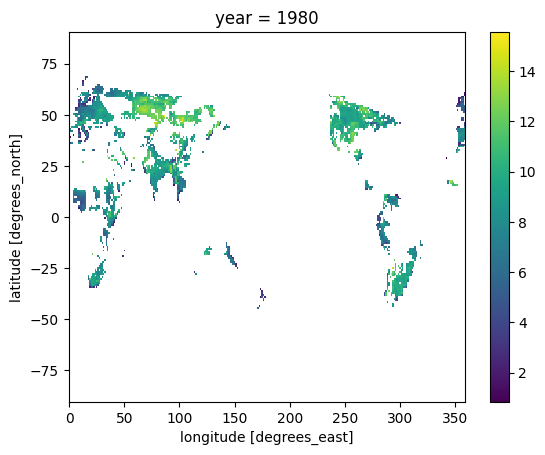

In [135]:
data = predictors["p00_tmax_mon1"] - predictors["p01_tmin_mon1"]
data.isel(year=0).plot()



## Predict with XGBoost crop emulator


In [136]:
# ============================================================
# 8. Load preprocessed predictors
# ============================================================

RESULTS_DIR = "/home/pmahlau/Uni_Arbeit/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

PREDICTORS_FILE = os.path.join(RESULTS_DIR, "predictors_XGBpred38_GEPIC_A0_swh_rf_LE2-1001_1980-2009.nc")
PREDICTIONS_OUTFILE = os.path.join(RESULTS_DIR, "predictions_XGBpred38_GEPIC_A0_swh_rf_LE2-1001_1980-2009.nc")

predictors = xr.open_dataset(PREDICTORS_FILE)
predictors




<xarray.Dataset>
Dimensions:                       (year: 30, lat: 192, lon: 288)
Coordinates:
  * year                          (year) int64 1980 1981 1982 ... 2007 2008 2009
  * lat                           (lat) float64 -90.0 -89.06 ... 89.06 90.0
  * lon                           (lon) float64 0.0 1.25 2.5 ... 357.5 358.8
Data variables: (12/55)
    p00_tmax_mon1                 (year, lat, lon) float32 ...
    p01_tmin_mon1                 (year, lat, lon) float32 ...
    p02_solar_mon1                (year, lat, lon) float32 ...
    p03_prec_mon1                 (year, lat, lon) float64 ...
    p04_tmax_mon2                 (year, lat, lon) float32 ...
    p05_tmin_mon2                 (year, lat, lon) float32 ...
    ...                            ...
    p49_gs_sd_solar               (year, lat, lon) float32 ...
    p50_consecutive_drought_days  (year, lat, lon) float32 ...
    p51_soil_type                 (year, lat, lon) float32 ...
    p52_co2_ppm                   (year, lat, lon) float32 ...
    p53_n_fertilizer_kg_ha        (year, lat, lon) float32 ...
    p54_growing_season_length     (year, lat, lon) float32 ...
Attributes:
    description:         XGBoost features f0-f54 stored as predictors p00-p54...
    crop:                spring wheat
    irrigation:          rainfed
    crop_model:          GEPIC
    scenario:            A0
    cesm_member:         LE2-1001
    years:               1980-2009
    co2_ppm:             360.0
    n_fertilizer_kg_ha:  60.0
    notes:               Monthly features are interleaved by month (Tmax, Tmi...

In [137]:
# ============================================================
# 9. Prepare feature matrix for XGBoost
# ============================================================

# The Booster expects a normal 2D table:
# rows = samples, columns = features.
# Here one sample is one combination of year + lat + lon.

# Select predictors p00...p54 and sort them by number. Predictor names now
# directly match the Booster numbering: f0 receives p00, ..., f54 receives p54.
feature_vars = sorted(
    [name for name in predictors.data_vars if name.startswith("p") and name[1:3].isdigit()],
    key=lambda name: int(name[1:3]),
)

assert len(feature_vars) == booster.num_features(), (
    f"Expected {booster.num_features()} features, found {len(feature_vars)} predictors"
)

# Exact names protect against accidentally loading a NetCDF created with the
# old grouped monthly order. Re-run preprocessing if this assertion fails.
expected_feature_vars = []
for m in range(1, 11):
    feature = 4 * (m - 1)
    expected_feature_vars.extend([
        f"p{feature:02d}_tmax_mon{m}",
        f"p{feature + 1:02d}_tmin_mon{m}",
        f"p{feature + 2:02d}_solar_mon{m}",
        f"p{feature + 3:02d}_prec_mon{m}",
    ])

expected_feature_vars.extend([
    "p40_gdd",
    "p41_edd",
    "p42_gs_avg_tmax",
    "p43_gs_avg_tmin",
    "p44_gs_total_prec",
    "p45_gs_avg_solar",
    "p46_gs_sd_tmax",
    "p47_gs_sd_tmin",
    "p48_gs_sd_prec",
    "p49_gs_sd_solar",
    "p50_consecutive_drought_days",
    "p51_soil_type",
    "p52_co2_ppm",
    "p53_n_fertilizer_kg_ha",
    "p54_growing_season_length",
])

assert feature_vars == expected_feature_vars, (
    "Predictor names do not match the Booster mapping. "
    "Re-run preprocessing to replace the old predictor NetCDF."
)

xgb_feature_names = booster.feature_names or [f"f{i}" for i in range(len(feature_vars))]
feature_map = pd.DataFrame({"xgb_feature": xgb_feature_names, "predictor": feature_vars})
print(feature_map.to_string(index=False))

# Convert 55 separate year x lat x lon variables into one feature dimension.
X = predictors[feature_vars].to_array("feature").transpose("year", "lat", "lon", "feature")

# Keep only samples for which every required feature is available.
valid = np.isfinite(X).all("feature")

# Flatten year x lat x lon into rows for XGBoost.
X_stacked = X.stack(sample=("year", "lat", "lon")).transpose("sample", "feature")
valid_stacked = valid.stack(sample=("year", "lat", "lon"))
valid_samples = valid_stacked.where(valid_stacked, drop=True).sample
X_valid = X_stacked.sel(sample=valid_samples)

print("All possible samples:", X_stacked.sizes["sample"])
print("Prediction rows:", X_valid.sizes["sample"])
print("Features:", len(feature_vars))
X_stacked



xgb_feature                    predictor
         f0                p00_tmax_mon1
         f1                p01_tmin_mon1
         f2               p02_solar_mon1
         f3                p03_prec_mon1
         f4                p04_tmax_mon2
         f5                p05_tmin_mon2
         f6               p06_solar_mon2
         f7                p07_prec_mon2
         f8                p08_tmax_mon3
         f9                p09_tmin_mon3
        f10               p10_solar_mon3
        f11                p11_prec_mon3
        f12                p12_tmax_mon4
        f13                p13_tmin_mon4
        f14               p14_solar_mon4
        f15                p15_prec_mon4
        f16                p16_tmax_mon5
        f17                p17_tmin_mon5
        f18               p18_solar_mon5
        f19                p19_prec_mon5
        f20                p20_tmax_mon6
        f21                p21_tmin_mon6
        f22               p22_solar_mon6
        f23     

<xarray.DataArray (sample: 1658880, feature: 55)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * feature  (feature) object 'p00_tmax_mon1' ... 'p54_growing_season_length'
  * sample   (sample) object MultiIndex
  * year     (sample) int64 1980 1980 1980 1980 1980 ... 2009 2009 2009 2009
  * lat      (sample) float64 -90.0 -90.0 -90.0 -90.0 ... 90.0 90.0 90.0 90.0
  * lon      (sample) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    description:         XGBoost features f0-f54 stored as predictors p00-p54...
    crop:                spring wheat
    irrigation:          rainfed
    crop_model:          GEPIC
    scenario:            A0
    cesm_member:         LE2-1001
    years:               1980-2009
    co2_ppm:             360.0
    n_fertilizer_kg_ha:  60.0
    notes:               Monthly features are interleaved by month (Tmax, Tmi...

In [138]:
# ============================================================
# 10. Predict and reshape back to grid
# ============================================================

# XGBoost works with NumPy arrays, not directly with xarray objects.
# Shape here: valid_samples x 55 features.
X_values = X_valid.values.astype(np.float32)

# DMatrix is the native XGBoost data container for prediction.
# We pass the feature names so XGBoost can match f0...f54 consistently.
dmatrix = xgb.DMatrix(X_values, feature_names=xgb_feature_names)

# One prediction for each valid year-gridcell sample.
pred_valid = booster.predict(dmatrix).astype(np.float32)
print("Prediction shape:", pred_valid.shape)

# Create an output array for all global samples and fill invalid locations with NaN.
# This lets us reshape predictions back to the original year x lat x lon grid.
pred_values = np.full(X_stacked.sizes["sample"], np.nan, dtype=np.float32)
pred_values[np.flatnonzero(valid_stacked.values)] = pred_valid

# Convert back from flat sample dimension to xarray coordinates.
# unstack("sample") restores the MultiIndex sample into year, lat, lon.
yield_prediction = xr.DataArray(
    pred_values,
    dims=["sample"],
    coords={"sample": X_stacked.sample},
    name="yield_prediction",
).unstack("sample")

yield_prediction.attrs["description"] = "XGBoost crop emulator prediction"
yield_prediction.attrs["model"] = "XGBpred38_GEPIC_A0_swh_rf"
yield_prediction.attrs["input_predictors"] = PREDICTORS_FILE

predictions = yield_prediction.to_dataset()
predictions.to_netcdf(PREDICTIONS_OUTFILE)

print(predictions)
print(f"saved: {PREDICTIONS_OUTFILE}")



Prediction shape: (78172,)
<xarray.Dataset>
Dimensions:           (year: 30, lat: 192, lon: 288)
Coordinates:
  * year              (year) int64 1980 1981 1982 1983 ... 2006 2007 2008 2009
  * lat               (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon               (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    yield_prediction  (year, lat, lon) float32 nan nan nan nan ... nan nan nan
saved: /home/pmahlau/Uni_Arbeit/results/predictions_XGBpred38_GEPIC_A0_swh_rf_LE2-1001_1980-2009.nc


## Explore prediction results


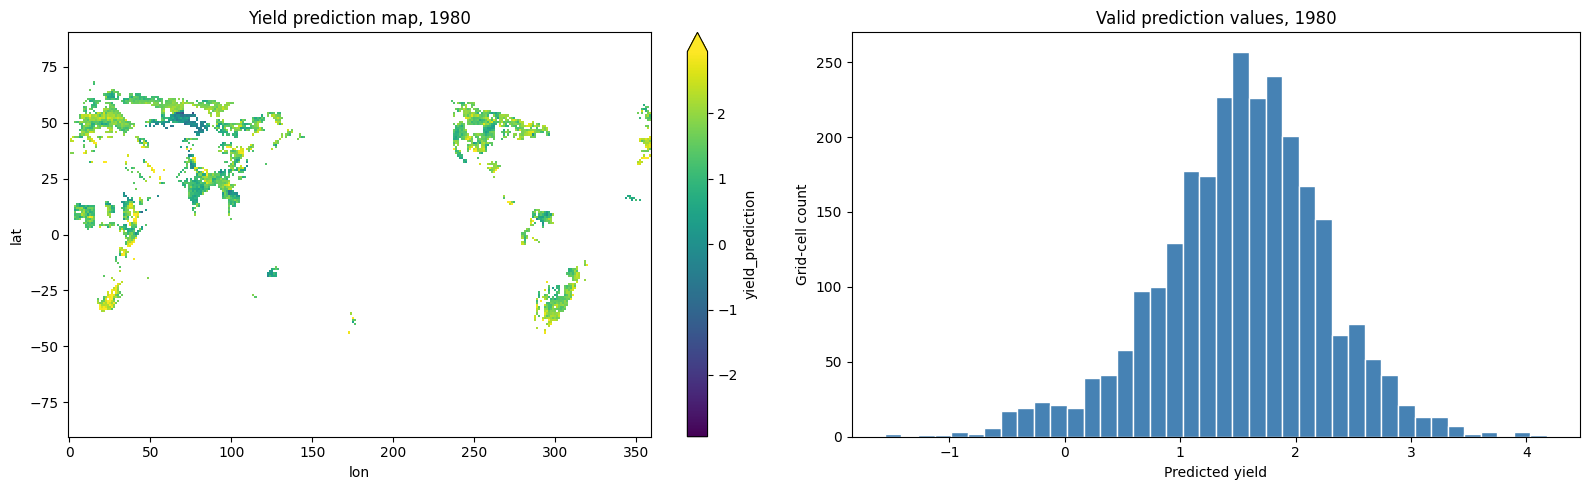

Valid prediction count: 2692
Min: -1.5592321
Mean: 1.5219632
Max: 4.178283


In [139]:
# ============================================================
# 11. Plot prediction map and distribution for one year
# ============================================================

plot_year = int(yield_prediction.year.values[0])
pred_year = yield_prediction.sel(year=plot_year)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Spatial map. Most global cells are NaN because we only predict spring wheat cells.
pred_year.plot(ax=axes[0], cmap="viridis", robust=True)
axes[0].set_title(f"Yield prediction map, {plot_year}")

# Histogram of valid prediction values only.
pred_year_valid = pred_year.values[np.isfinite(pred_year.values)]
axes[1].hist(pred_year_valid, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title(f"Valid prediction values, {plot_year}")
axes[1].set_xlabel("Predicted yield")
axes[1].set_ylabel("Grid-cell count")

plt.tight_layout()
plt.show()

print("Valid prediction count:", pred_year_valid.size)
print("Min:", np.nanmin(pred_year_valid))
print("Mean:", np.nanmean(pred_year_valid))
print("Max:", np.nanmax(pred_year_valid))



In [140]:
# ============================================================
# 12. Inspect valid prediction values for one year
# ============================================================

# Convert the selected prediction year to a table and drop invalid grid cells.
# This is easier to inspect than printing the full global grid, which is mostly NaN.
valid_prediction_values = (
    pred_year
    .to_dataframe()
    .dropna()
    .reset_index()
    .sort_values("yield_prediction")
)

print("Valid values for year:", plot_year)
print("Rows:", len(valid_prediction_values))
print(valid_prediction_values.describe())

# In a notebook, displaying the DataFrame lets you scroll/search the valid values.
# Use .head() first if the full table is too long.
valid_prediction_values



Valid values for year: 1980
Rows: 2692
               lat          lon    year  yield_prediction
count  2692.000000  2692.000000  2692.0       2692.000000
mean     29.185253   133.297270  1980.0          1.521963
std      27.972828   109.737364     0.0          0.725253
min     -43.821990     1.250000  1980.0         -1.559232
25%      11.780105    37.500000  1980.0          1.095637
50%      40.994764    91.250000  1980.0          1.560562
75%      50.418848   255.000000  1980.0          1.983890
max      68.324607   358.750000  1980.0          4.178283


,lat,lon,year,yield_prediction
2297,54.188482,70.00,1980,-1.559232
2298,54.188482,76.25,1980,-1.504483
2296,54.188482,68.75,1980,-1.141672
2294,54.188482,66.25,1980,-0.990170
2295,54.188482,67.50,1980,-0.949565
...,...,...,...,...
1178,34.397906,76.25,1980,3.692179
746,14.607330,271.25,1980,3.980875
530,7.068063,41.25,1980,4.000139
1179,34.397906,77.50,1980,4.034738


Overall performance across all common years
Reference yield units: t ha-1 yr-1
Compared years: 1980 - 2009
Valid pairs: 78056
R2: -0.401 | Correlation: 0.168 | MAE: 0.830 | RMSE: 1.059 | Bias: -0.147


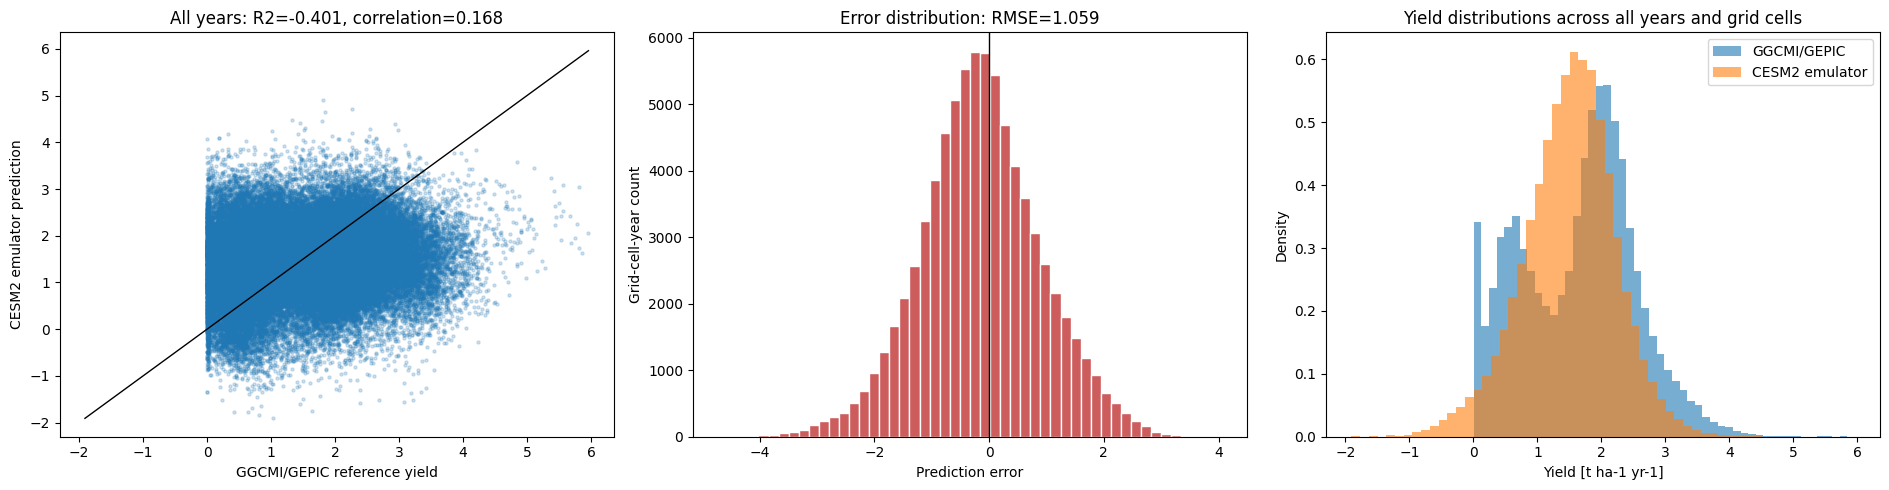

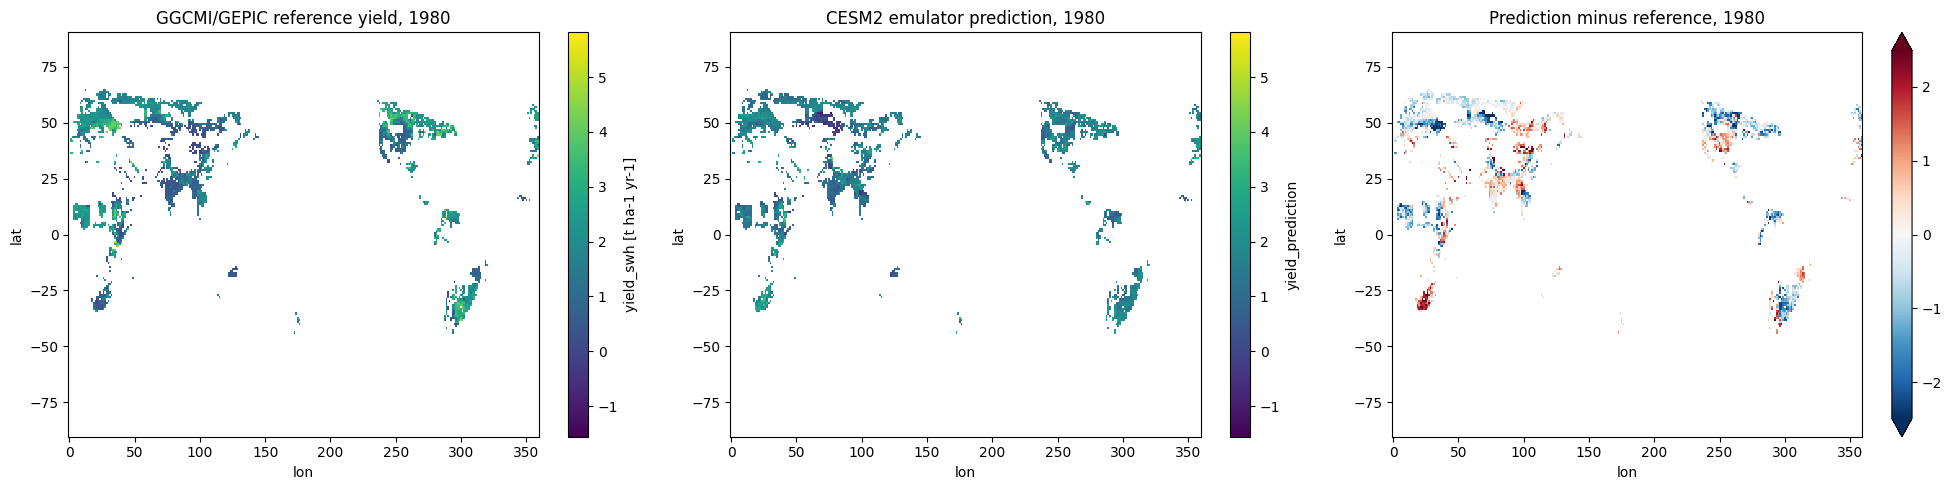

Performance for 1980
Valid grid cells: 2688
R2: -0.299 | Correlation: 0.194 | MAE: 0.906 | RMSE: 1.146 | Bias: -0.243


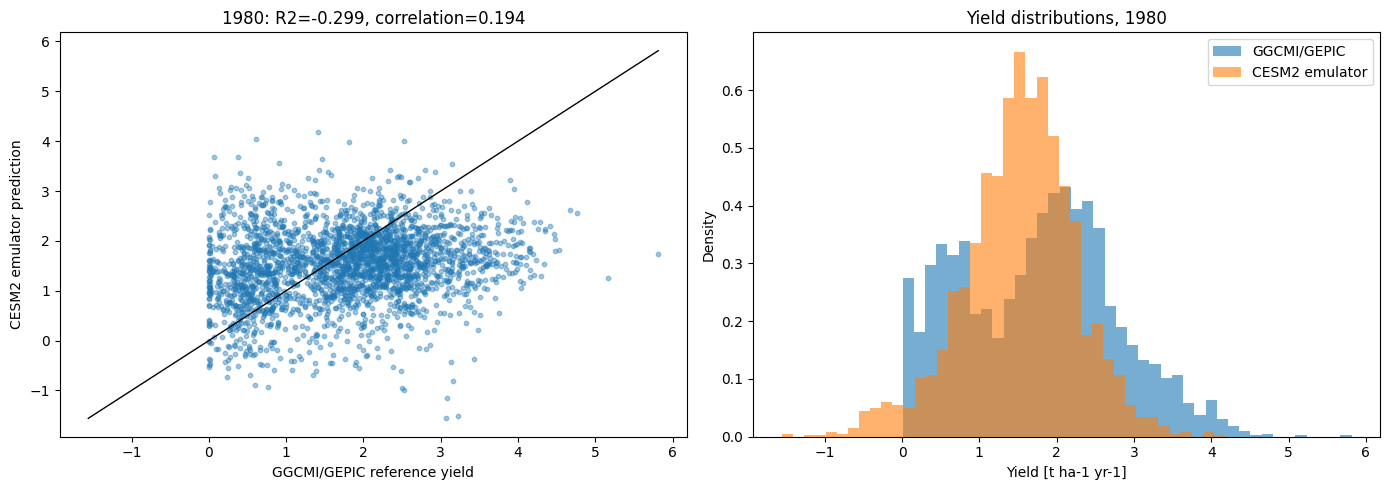

In [141]:
# ============================================================
# 13. Performance assessment against GGCMI/GEPIC reference yield
# ============================================================

TARGET_YIELD_FILE = "/home/pmahlau/Uni_Arbeit/data/crop_data/ggcmi_phase_2_data/GEPIC_spring_wheat_A0_yield_unpacked/yield/gepic_agmerra_fullharm_yield_swh_global_annual_1980_2010_C360_T0_W0_N60_A0.nc4"
TARGET_YIELD_VAR = "yield_swh"
COMPARE_YEAR = 1980

# GGCMI time values 1...31 represent growing seasons 1980...2010.
target_ds = xr.open_dataset(TARGET_YIELD_FILE, decode_times=False)
yield_true = target_ds[TARGET_YIELD_VAR]
raw_time = yield_true["time"].values.astype(int)
yield_true = yield_true.assign_coords(year=("time", 1979 + raw_time)).swap_dims({"time": "year"})

# Keep common years and align the 0.5 degree GGCMI data to the CESM2 grid.
yield_true = yield_true.sel(
    year=slice(int(yield_prediction.year.min()), int(yield_prediction.year.max()))
)
yield_true = align_to_grid(yield_true, yield_prediction, method="nearest")
yield_true, yield_pred = xr.align(yield_true, yield_prediction, join="inner")

# Compare only paired values with positive reference yield. Negative emulator
# predictions remain included because they are part of model performance.
eval_mask = np.isfinite(yield_true) & np.isfinite(yield_pred) & (yield_true > 0)
y_true_values = yield_true.where(eval_mask).values.ravel()
y_pred_values = yield_pred.where(eval_mask).values.ravel()
valid_eval = np.isfinite(y_true_values) & np.isfinite(y_pred_values)
y_true_values = y_true_values[valid_eval]
y_pred_values = y_pred_values[valid_eval]

error = y_pred_values - y_true_values
mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error ** 2))
bias = np.mean(error)
r2 = 1 - np.sum(error ** 2) / np.sum((y_true_values - np.mean(y_true_values)) ** 2)
correlation = np.corrcoef(y_true_values, y_pred_values)[0, 1]

print("Overall performance across all common years")
print("Reference yield units:", yield_true.attrs.get("units", "not specified"))
print("Compared years:", int(yield_true.year.min()), "-", int(yield_true.year.max()))
print("Valid pairs:", len(y_true_values))
print(f"R2: {r2:.3f} | Correlation: {correlation:.3f} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | Bias: {bias:.3f}")

# Overall scatterplot, error distribution, and yield distributions.
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
lims = [min(y_true_values.min(), y_pred_values.min()), max(y_true_values.max(), y_pred_values.max())]
axes[0].scatter(y_true_values, y_pred_values, s=5, alpha=0.2)
axes[0].plot(lims, lims, color="black", linewidth=1)
axes[0].set_xlabel("GGCMI/GEPIC reference yield")
axes[0].set_ylabel("CESM2 emulator prediction")
axes[0].set_title(f"All years: R2={r2:.3f}, correlation={correlation:.3f}")

axes[1].hist(error, bins=50, color="indianred", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Prediction error")
axes[1].set_ylabel("Grid-cell-year count")
axes[1].set_title(f"Error distribution: RMSE={rmse:.3f}")

axes[2].hist(y_true_values, bins=50, density=True, alpha=0.6, label="GGCMI/GEPIC")
axes[2].hist(y_pred_values, bins=50, density=True, alpha=0.6, label="CESM2 emulator")
axes[2].set_xlabel("Yield [t ha-1 yr-1]")
axes[2].set_ylabel("Density")
axes[2].set_title("Yield distributions across all years and grid cells")
axes[2].legend()
plt.tight_layout()
plt.show()

# Compare maps for one selected year using exactly the same valid grid cells.
true_year = yield_true.sel(year=COMPARE_YEAR)
pred_year = yield_pred.sel(year=COMPARE_YEAR)
year_mask = np.isfinite(true_year) & np.isfinite(pred_year) & (true_year > 0)
true_year_paired = true_year.where(year_mask)
pred_year_paired = pred_year.where(year_mask)
error_year = pred_year_paired - true_year_paired

map_vmin = min(float(true_year_paired.min()), float(pred_year_paired.min()))
map_vmax = max(float(true_year_paired.max()), float(pred_year_paired.max()))
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
true_year_paired.plot(ax=axes[0], cmap="viridis", vmin=map_vmin, vmax=map_vmax)
axes[0].set_title(f"GGCMI/GEPIC reference yield, {COMPARE_YEAR}")
pred_year_paired.plot(ax=axes[1], cmap="viridis", vmin=map_vmin, vmax=map_vmax)
axes[1].set_title(f"CESM2 emulator prediction, {COMPARE_YEAR}")
error_year.plot(ax=axes[2], cmap="RdBu_r", center=0, robust=True)
axes[2].set_title(f"Prediction minus reference, {COMPARE_YEAR}")
plt.tight_layout()
plt.show()

# Metrics, scatterplot, and distributions for the selected year.
y_true_year_values = true_year_paired.values.ravel()
y_pred_year_values = pred_year_paired.values.ravel()
valid_year = np.isfinite(y_true_year_values) & np.isfinite(y_pred_year_values)
y_true_year_values = y_true_year_values[valid_year]
y_pred_year_values = y_pred_year_values[valid_year]
year_error = y_pred_year_values - y_true_year_values
year_mae = np.mean(np.abs(year_error))
year_rmse = np.sqrt(np.mean(year_error ** 2))
year_bias = np.mean(year_error)
year_r2 = 1 - np.sum(year_error ** 2) / np.sum((y_true_year_values - np.mean(y_true_year_values)) ** 2)
year_corr = np.corrcoef(y_true_year_values, y_pred_year_values)[0, 1]

print(f"Performance for {COMPARE_YEAR}")
print("Valid grid cells:", len(y_true_year_values))
print(f"R2: {year_r2:.3f} | Correlation: {year_corr:.3f} | MAE: {year_mae:.3f} | RMSE: {year_rmse:.3f} | Bias: {year_bias:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
year_lims = [min(y_true_year_values.min(), y_pred_year_values.min()), max(y_true_year_values.max(), y_pred_year_values.max())]
axes[0].scatter(y_true_year_values, y_pred_year_values, s=10, alpha=0.4)
axes[0].plot(year_lims, year_lims, color="black", linewidth=1)
axes[0].set_xlabel("GGCMI/GEPIC reference yield")
axes[0].set_ylabel("CESM2 emulator prediction")
axes[0].set_title(f"{COMPARE_YEAR}: R2={year_r2:.3f}, correlation={year_corr:.3f}")
axes[1].hist(y_true_year_values, bins=40, density=True, alpha=0.6, label="GGCMI/GEPIC")
axes[1].hist(y_pred_year_values, bins=40, density=True, alpha=0.6, label="CESM2 emulator")
axes[1].set_xlabel("Yield [t ha-1 yr-1]")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Yield distributions, {COMPARE_YEAR}")
axes[1].legend()
plt.tight_layout()
plt.show()



In [142]:
target_ds

<xarray.Dataset>
Dimensions:    (lon: 720, lat: 360, time: 31)
Coordinates:
  * lon        (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat        (lat) float32 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time       (time) float32 1.0 2.0 3.0 4.0 5.0 ... 27.0 28.0 29.0 30.0 31.0
Data variables:
    yield_swh  (time, lat, lon) float32 ...
Attributes:
    title:        Model output for GGCMI phase 2
    institution:  IIASA
    contact:      folberth@iiasa.ac.at